# 职业选手新版准星：2026-10-08 全高度重筛与组合分析

## 主要结果

以 2026-10-05 官方 VRS Top30 为范围，10 月 8 日采集的 133 条准星记录中有 99 条 cs2-v1。**94 条为静态十字，全部参考高度均纳入**，来自 22 支战队；其余 5 条形状另列，不作为缺失删除。页面日期不再限制主样本，75 条 10 月核验的静态十字作为时效敏感性检查。

按来源高度换算到 1080 的连续等效像素，最常见已提取外观组合有 **26/94（27.7%）**：2.25 / 1.125 / 2.25，无点、无描边、非 T 型、alpha 255。原始参数 2 / 1 / 2 的完整外观组合有 **36/94（38.3%）**，分散于不同高度，不能全部称作同一比例尺寸。最常见组仍是多数之外的起步选项。

## 方法与边界

- 比较值 = 原始参数 × 1080 / screenHeight；采用精确分数计数，不以四舍五入标签合并。
- 1080 是展示单位，不是筛选条件；改成其他目标高度不改变比例相等的分组和人数。
- [Valve 9 月 24 日说明](https://steamcommunity.com/games/CSGO/announcements/detail/1844751498219795)明确分辨率改变后自动按比例缩放。等效像素不是游戏实际渲染像素，不做取整，也不生成可执行的小数设置。间距偏移不等于中心空洞宽度。
- 主分析比较来源参数的相对尺度，不模拟显示器物理大小、4:3 拉伸、半描边或实际引擎渲染。未提取的字段不能被视为相同。
- lastVerified 是页面核验时间，不能证明实战使用或主动更换设置；99 条新版中有 4 条日期早于系统更新，保留并标注风险。
- 颜色统计使用全部 99 条新版记录；旧格式留在覆盖和质量检查中，不混入新版几何推荐。
- 此前的 54 条同高度近期样本及其关联／聚类保留为附录敏感性分析，不能替代 94 条主结果。

来源：[CS2Settings](https://cs2settings.com/players)、[官方 VRS](https://github.com/ValveSoftware/counter-strike_regional_standings/blob/main/live/2026/standings_global_2026_10_05.md)。公开输入只有聚合计数，逐人数据留在 work/。


## Data

### 1. 加载公开计数并验证来源与分母

In [1]:
from pathlib import Path
import json, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "scripts/crosshair_analysis.py").exists())
sys.path.insert(0, str(root / "scripts"))
from crosshair_analysis import analyze, expand_joint, distances, medoids, canonical_hash

input_path = root / "data/aggregate/analysis/2026-10-08-crosshair.json"
review = json.loads(input_path.read_text())
snapshot = json.loads((root / "data/aggregate/2026-10-08.json").read_text())
assert review["input_metric_sha256"] == canonical_hash(snapshot["aggregate"])
assert review["collection"]["collection_complete"]
assert review["ranking_date"] == "2026-10-05"
assert sum(r["count"] for r in review["geometry_sample"]["combinations"]) == review["geometry_sample"]["valid_n"]
print("Snapshot:", review["snapshot_date"], "VRS:", review["ranking_date"])
print("Collection:", review["collection"])
print("Identity duplicates / domain errors / future page dates:", review["quality"]["identity_duplicate_n"], review["quality"]["invalid_values"], review["quality"]["future_page_date_n"])
print("Source roster size anomalies:", review["quality"]["roster_size_outliers"])
print("Historical 960-height recent subset:", review["geometry_sample"]["valid_n"], "Reference height:", review["geometry_sample"]["reference_height"])
plt.rcParams.update({"figure.figsize": (9, 5), "font.size": 11, "axes.spines.top": False, "axes.spines.right": False})
figure_dir = root / "figures/analysis/2026-10-08"
figure_dir.mkdir(parents=True, exist_ok=True)


Snapshot: 2026-10-08 VRS: 2026-10-05
Collection: {'requested_core_teams': 30, 'successful_core_team_rosters': 30, 'expected_core_players': 151, 'successful_core_players': 151, 'collection_complete': True, 'incomplete_reasons': []}
Identity duplicates / domain errors / future page dates: 0 {} 0
Source roster size anomalies: [{'team': 'heroic', 'cohort_n': 6, 'crosshair_valid_n': 5, 'missing_n': 1}]
Historical 960-height recent subset: 54 Reference height: 960


### 2. 覆盖与筛选

主样本为全部 94 条可比新版静态十字；末行 75 条仅是近期页面敏感性样本。

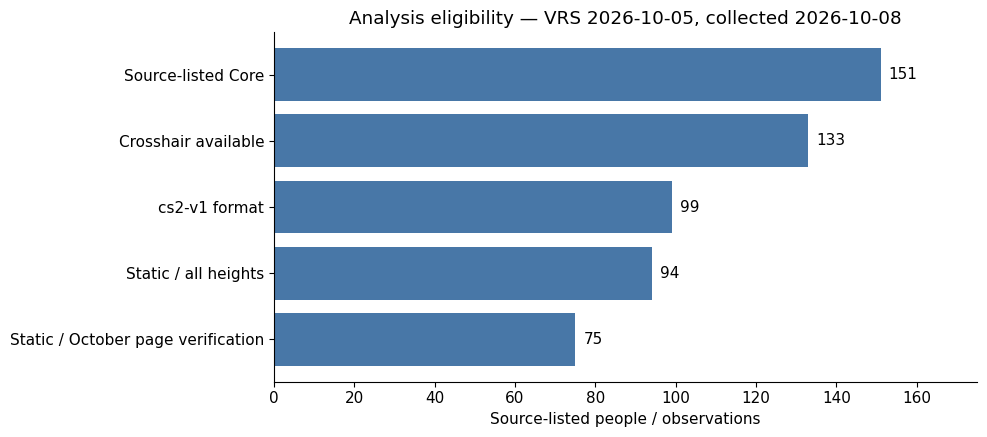

                         valid_n  missing_n  cohort_n
crosshair_format             133         18       151
crosshair_style              133         18       151
crosshair_size               133         18       151
crosshair_gap                133         18       151
crosshair_thickness          133         18       151
crosshair_screen_height      120         31       151
crosshair_dot                133         18       151
crosshair_outline_mode       133         18       151
crosshair_t_style            133         18       151
crosshair_alpha              133         18       151
crosshair_color_r            133         18       151
crosshair_color_g            133         18       151
crosshair_color_b            133         18       151


In [2]:
labels = ["Source-listed Core", "Crosshair available", "cs2-v1 format", "Static / all heights", "Static / October page verification"]
counts = [review["cohort_n"], review["crosshair_valid_n"], review["native_format_n"], review["rescreened"]["eligible_n"], review["rescreened"]["recent_page_appearance"]["valid_n"]]
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.barh(labels[::-1], counts[::-1], color="#4877a7")
for y, value in enumerate(counts[::-1]): ax.text(value+2, y, str(value), va="center")
ax.set_xlim(0, 175); ax.set_xlabel("Source-listed people / observations")
ax.set_title("Analysis eligibility — VRS 2026-10-05, collected 2026-10-08")
fig.tight_layout(); fig.savefig(figure_dir / "coverage.png", dpi=160); plt.show()
missing = pd.DataFrame(review["quality"]["field_completeness"]).T
print(missing.to_string())


### 3. 页面核验时间

4 条 cs2-v1 页面的核验日期早于系统更新，是时间语义或转换风险提示；不是 4 名选手已证实使用错误设置。旧格式缺少 screenHeight 属于结构性缺失，不应填充成显示高度。

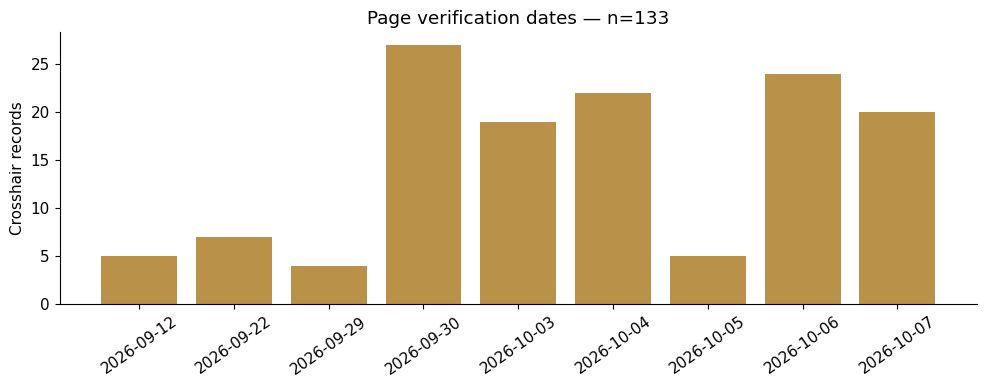

Pre-migration verified dates in native format: 4
Teams with missing crosshair data:
             team  cohort_n  crosshair_valid_n  missing_n
            3dmax         5                  4          1
               b8         5                  4          1
             faze         5                  3          2
      gamerlegion         5                  4          1
           heroic         6                  5          1
     inner-circle         5                  3          2
         jijiehao         5                  4          1
           legacy         5                  4          1
       luminosity         5                  3          2
            magic         5                  3          2
          nemesis         5                  4          1
           nemiga         5                  4          1
ninjas-in-pyjamas         5                  3          2


In [3]:
dates = review["quality"]["page_verified_dates"]["categories"]
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(list(dates), list(dates.values()), color="#b99149")
ax.set_ylabel("Crosshair records"); ax.set_title("Page verification dates — n="+str(sum(dates.values())))
ax.tick_params(axis="x", rotation=35)
fig.tight_layout(); fig.savefig(figure_dir / "freshness.png", dpi=160); plt.show()
print("Pre-migration verified dates in native format:", review["quality"]["native_format_before_system_update_n"])
print("Teams with missing crosshair data:")
print(pd.DataFrame([r for r in review["quality"]["team_coverage"] if r["missing_n"]]).to_string(index=False))


## 主结果：取消高度和页面日期限制

全部 94 条新版静态十字都具备参考高度和已提取外观参数，无高度相关的数据损失。原始参数相同与等比例参数相同分别排序。75 条 10 月页面核验记录用于敏感性检查，不再把页面较旧者自动剔除。其余 5 条新版形状为射击反馈十字 3、静态圆 1、纯点 1，保留在总体形状分布中。

26 条最常见等比例模板均来自原始参考高度 960：因此其原始可读配置仍是 2 / 1 / 2，显示为 1080 等效像素时为 2.25 / 1.125 / 2.25。颜色图用全部 99 条新版数据，不能与模板份额相乘推算整套人数。


Sample definition: all current cs2-v1 static crosses with complete extracted appearance and valid reference height; no height or page-date cutoff
Reference heights: {'valid_n': 94, 'categories': {'1024': 4, '1050': 2, '1080': 13, '768': 5, '800': 1, '864': 2, '900': 1, '960': 66}}
VRS rank bins: {'valid_n': 94, 'categories': {'1-10': 41, '11-20': 23, '21-30': 30}}
          team_id  valve_rank  count
      team-spirit           1      5
           legacy           2      4
         vitality           3      4
             mouz           4      5
               g2           5      4
          falcons           6      4
            furia           7      5
           aurora           9      5
         astralis          10      5
          betboom          11      5
               b8          13      4
           nemiga          14      3
       luminosity          16      3
               9z          17      5
ninjas-in-pyjamas          18      3
              m80          22      5
    

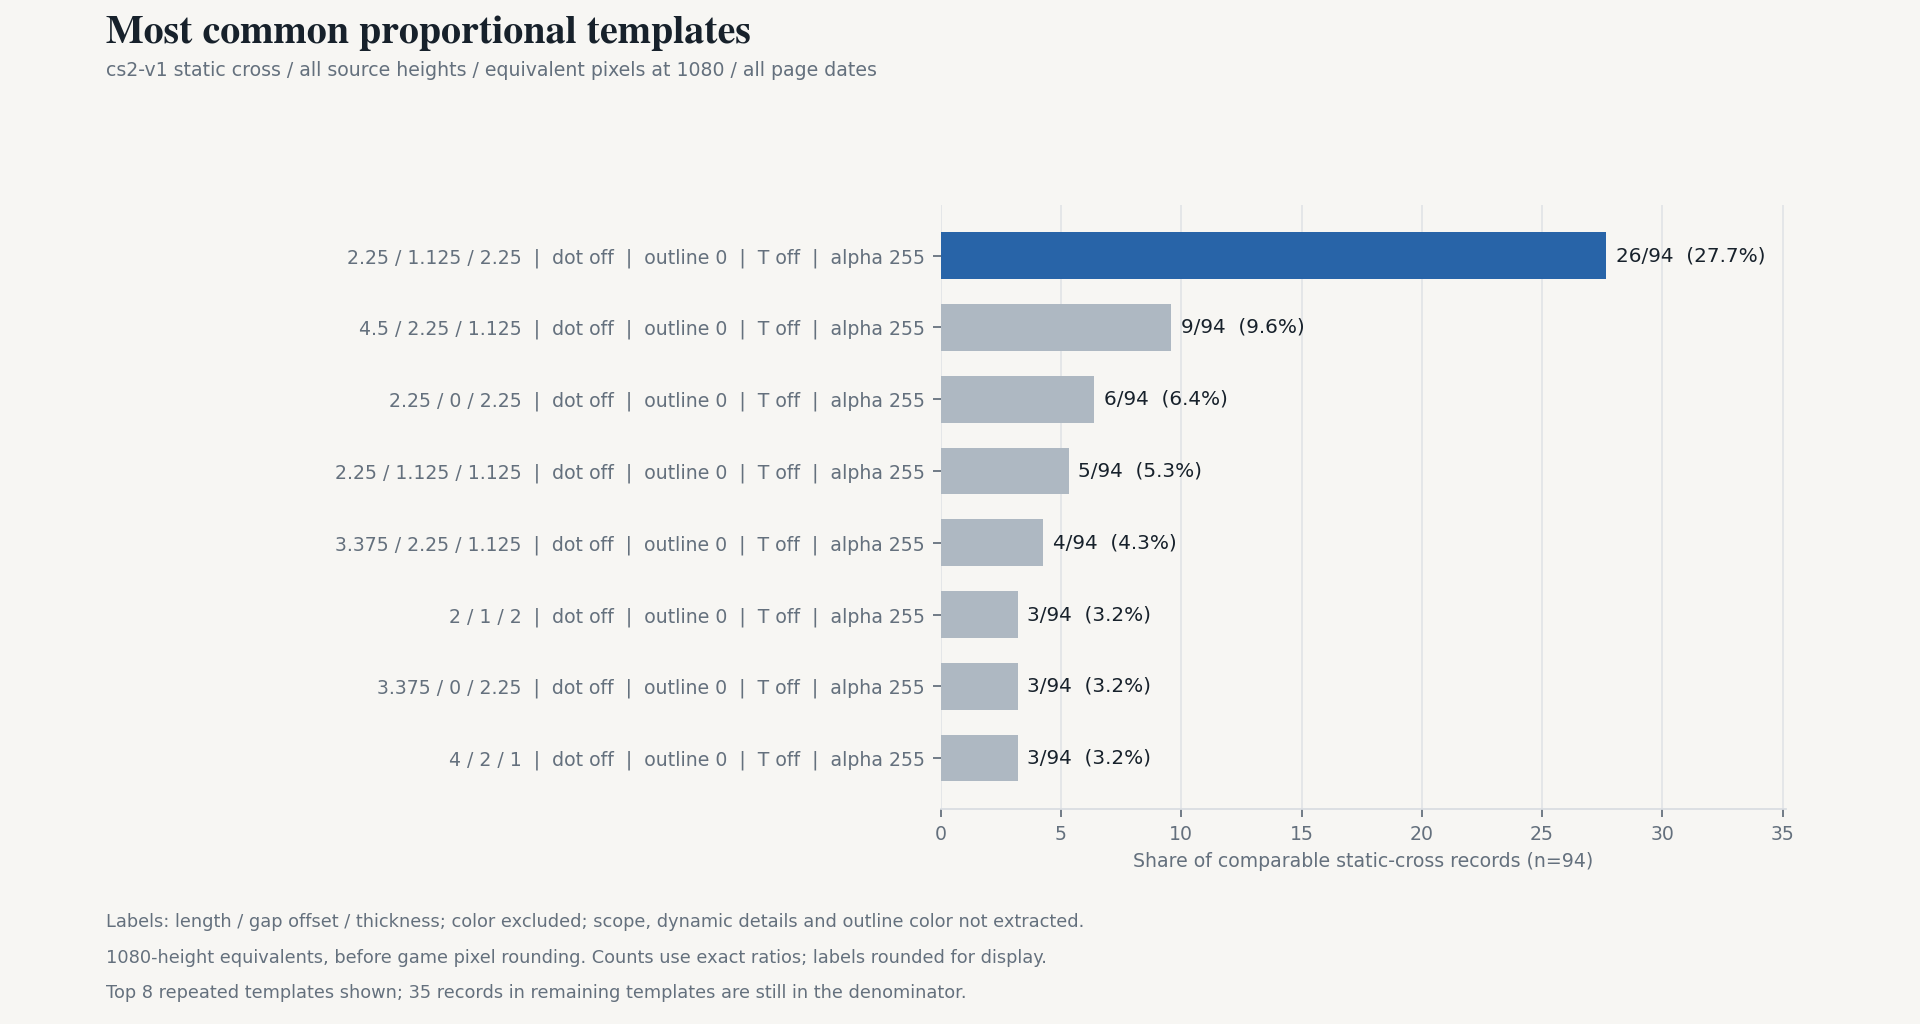

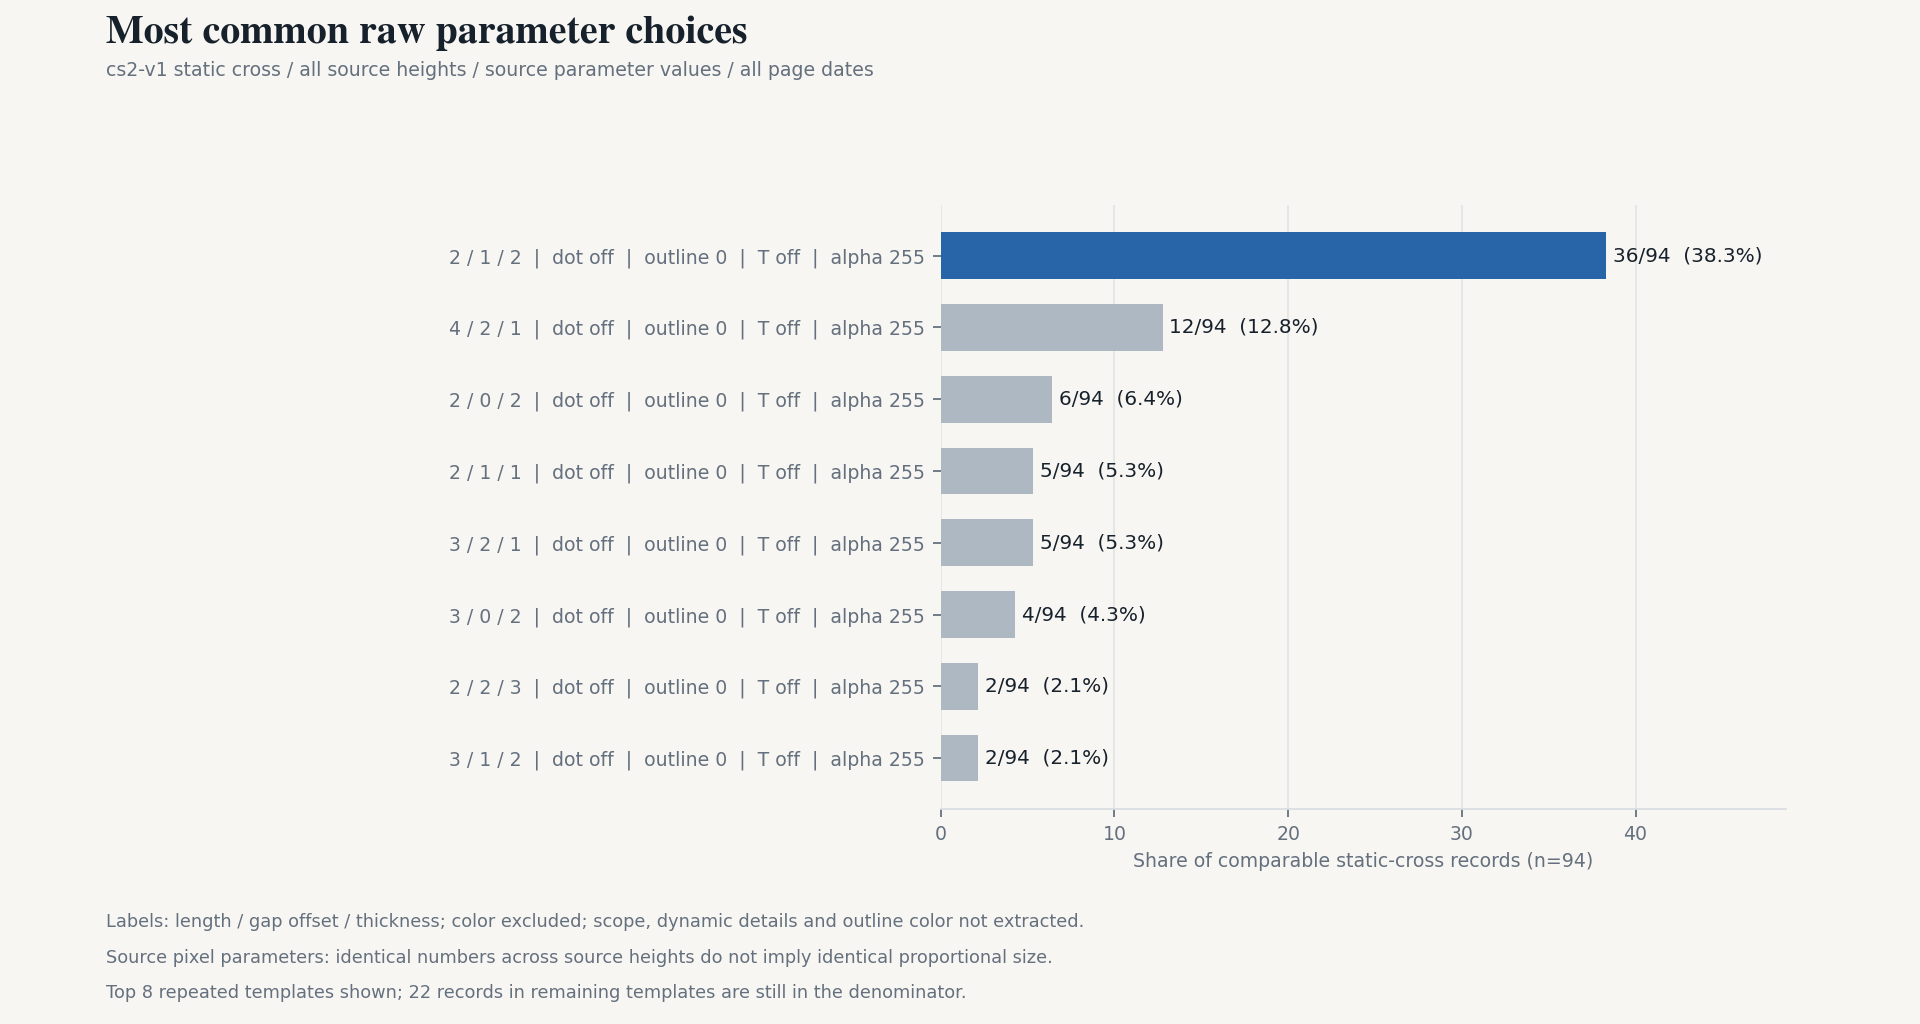

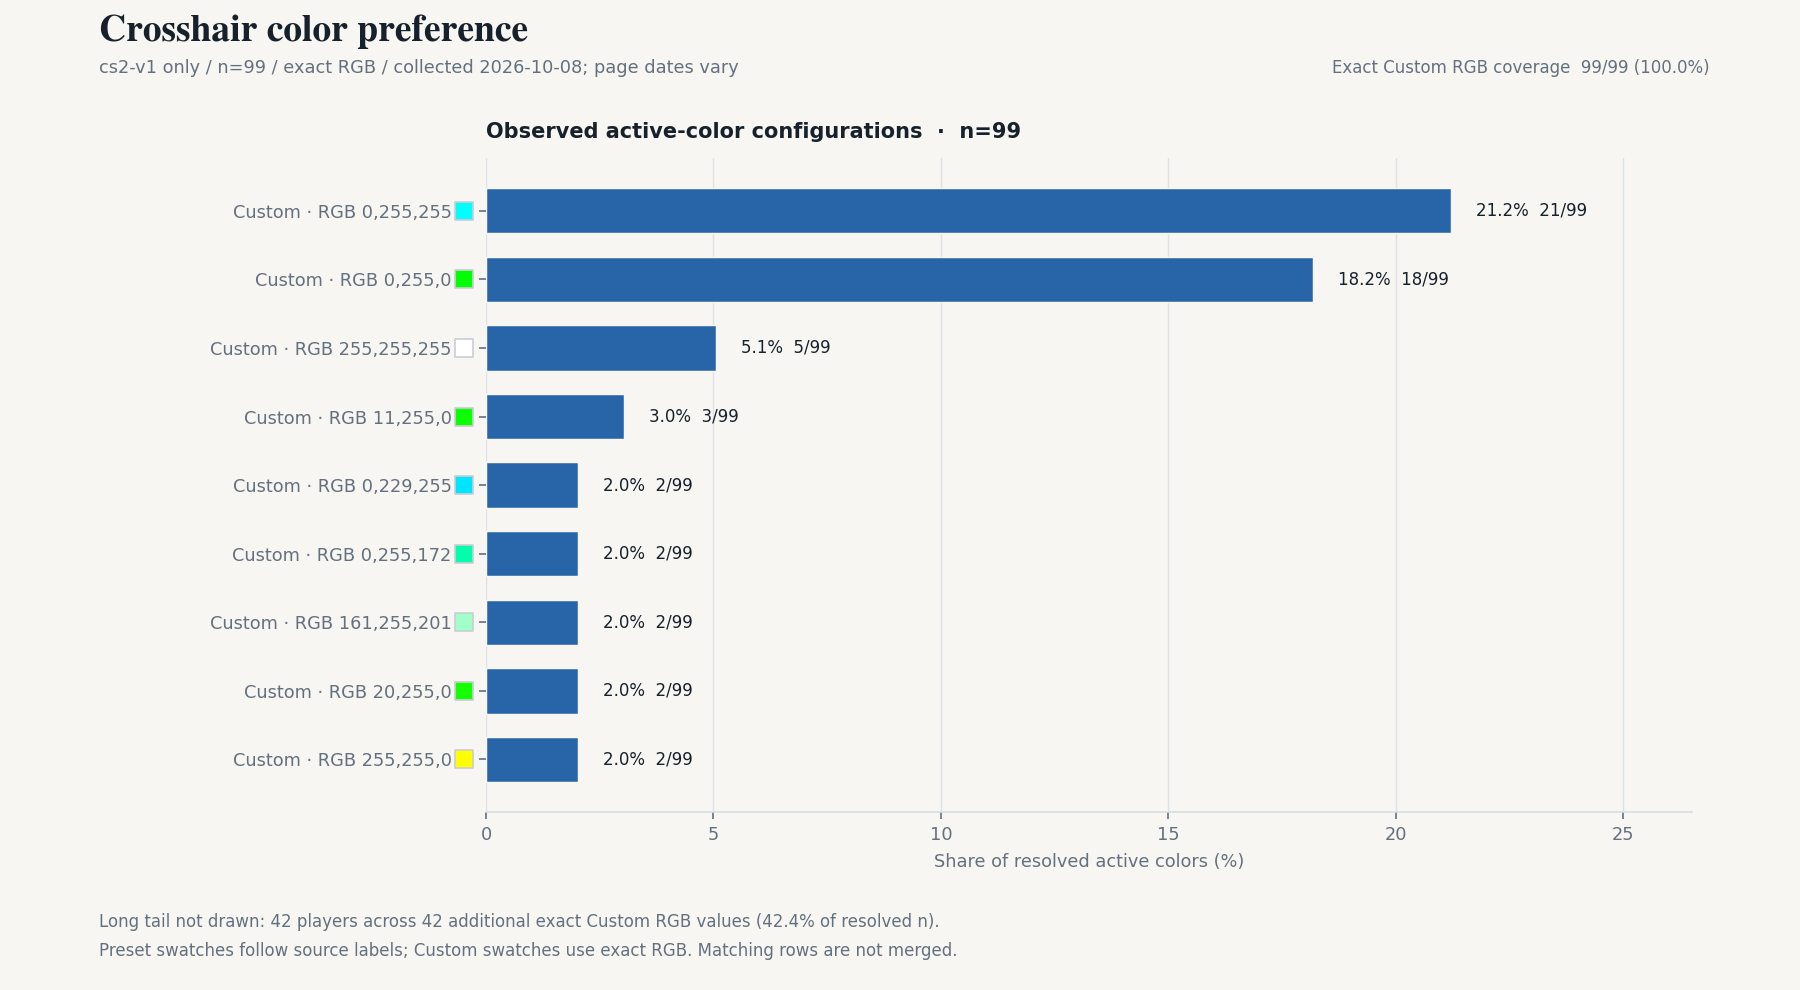

In [4]:
from crosshair_recommendation import render
from IPython.display import display, Image
sample = review["rescreened"]
assert sample["eligible_n"] + sample["incomplete_static_n"] == sample["static_n"]
assert sample["static_n"] + sample["other_styles_n"] == sample["native_n"]
assert sample["source_height_counts"]["valid_n"] == sample["eligible_n"]
for key in ["appearance", "raw_parameter_appearance", "recent_page_appearance"]:
    block = sample[key]
    assert sum(r["count"] for r in block["combinations"]) + block["singleton_n"] == block["valid_n"]
for key in ["geometry", "recent_page_geometry"]:
    assert sum(r["count"] for r in sample[key]["combinations"]) == sample[key]["valid_n"]
assert sum(review["native_colors"]["categories"].values()) == review["native_colors"]["valid_n"]
print("Sample definition:", sample["selection"])
print("Reference heights:", sample["source_height_counts"])
print("VRS rank bins:", sample["rank_bins"])
print(pd.DataFrame(sample["team_counts"]).to_string(index=False))
print("Normalized repeated appearance combinations:")
print(pd.DataFrame(sample["appearance"]["combinations"]).to_string(index=False))
print("Recent-page sensitivity: n=", sample["recent_page_appearance"]["valid_n"], "top=", sample["recent_page_appearance"]["combinations"][0])
print("Normalized geometry Spearman:")
print(pd.DataFrame(sample["geometry"]["spearman"]).round(3).to_string())
for chart in render(review, figure_dir):
    display(Image(filename=str(chart)))


## 附录：此前 54 条同高度近期样本

### 4. 同高度子样本的几何组合与关联

每个气泡是图中两参数相同的记录计数；第三参数在投影中合并，完整三参数组合见表。气泡面积表示人数。相关系数为描述性关联，无因果或命中率含义。

In [5]:
results = analyze(review)
assert results == review["analysis"], "Analysis changed; regenerate and review the published aggregate"
joint = pd.DataFrame(review["geometry_sample"]["combinations"])
print(joint.head(10).to_string(index=False))
print("Spearman correlations:")
print(pd.DataFrame(results["spearman"]).round(3).to_string())
# Two views keep gap and thickness visible without point-level identities.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, dimension in zip(axes, ["thickness", "gap_offset"]):
    cells = joint.groupby(["length", dimension], as_index=False)["count"].sum()
    ax.scatter(cells["length"], cells[dimension], s=cells["count"]*35, color="#4877a7", alpha=.7, edgecolor="#263d52")
    for row in cells.itertuples(index=False):
        if row.count >= 3: ax.text(row.length, getattr(row, dimension), str(row.count), ha="center", va="center", fontsize=10)
    ax.set_xlim(cells["length"].min()-.5, cells["length"].max()+.5)
    ax.set_xlabel("Bar length (px @ 960)"); ax.set_ylabel(dimension.replace("_", " ")+" (px @ 960)")
    ax.set_ylim(cells[dimension].min()-.7, cells[dimension].max()+.7)
    ax.set_title("Length vs "+dimension.replace("_", " "))
fig.suptitle("Recent-page static crosses — n="+str(results["sample_n"])+"; area = count")
fig.tight_layout(); fig.savefig(figure_dir / "geometry-combinations.png", dpi=160); plt.show()


 length  gap_offset  thickness  count
    2.0         1.0        2.0     22
    2.0         0.0        2.0      6
    4.0         2.0        1.0      6
    2.0         1.0        1.0      4
    3.0         2.0        1.0      4
    3.0         0.0        1.0      2
    3.0         0.0        2.0      2
    2.0         1.0        3.0      1
    2.0         2.0        2.0      1
    2.0         3.0        1.0      1
Spearman correlations:
            length  gap_offset  thickness
length       1.000       0.546     -0.550
gap_offset   0.546       1.000     -0.453
thickness   -0.550      -0.453      1.000


### 5. 探索性分组与敏感性

在保留合理组大小的候选中，两组的轮廓系数最高。组中心为真实出现的参数组合。41/13 是算法划分人数，不是恰好使用代表组合的人数。

In [6]:
print("Candidate partitions:")
print(pd.DataFrame(results["candidates"]).to_string(index=False))
print("Groups:")
print(pd.DataFrame(results.get("groups", [])).to_string(index=False))
print("Sensitivity:", results.get("sensitivity"))
print("All-page-date sensitivity:", results["all_date_sensitivity"])
if results["selected"]:
    x = expand_joint(review["geometry_sample"])
    d, _ = distances(x); centers, labels = medoids(d, results["selected"]["k"])
    fig, axes = plt.subplots(1, 3, figsize=(11, 4.2))
    for column, (ax, name) in enumerate(zip(axes, ["Length", "Gap offset", "Thickness"])):
        values = [x[labels==i, column] for i in range(results["selected"]["k"])]
        ax.boxplot(values, showfliers=True)
        ax.set_xticks(range(1, len(values)+1), ["Group "+str(i+1) for i in range(len(values))])
        ax.set_title(name); ax.set_ylabel("px @ 960")
    fig.suptitle("Exploratory geometry groups — n="+str(len(x)))
    fig.tight_layout(); fig.savefig(figure_dir / "exploratory-groups.png", dpi=160); plt.show()


Candidate partitions:
 k  silhouette             sizes  minimum_size_pass
 2      0.6596          [41, 13]               True
 3      0.5891      [31, 13, 10]               True
 4      0.6375   [31, 11, 10, 2]              False
 5      0.6678 [29, 7, 10, 2, 6]              False
Groups:
 group  count          medoid          median             min             max
     1     41 [2.0, 1.0, 2.0] [2.0, 1.0, 2.0] [2.0, 0.0, 1.0] [3.0, 3.0, 3.0]
     2     13 [4.0, 2.0, 1.0] [4.0, 2.0, 1.0] [3.0, 2.0, 1.0] [6.0, 5.0, 2.0]
Sensitivity: {'bootstrap_runs': 50, 'bootstrap_ari_median': 1.0, 'bootstrap_ari_p10': 0.7116, 'length_weighted_ari': 1.0, 'unique_template_silhouette': 0.6079, 'caveat': 'Bootstrap resamples anonymous parameter tuples, not teams; it cannot test independent-source truth or team dependence.'}
All-page-date sensitivity: {'sample_n': 66, 'spearman': {'length': {'length': 1.0, 'gap_offset': 0.4835, 'thickness': -0.5306}, 'gap_offset': {'length': 0.4835, 'gap_offset': 1.0, 'thi

## 结论与边界

- 取消高度和页面日期筛选后，94 条新版静态十字全部进入主比较。99 条新版的全部形状及颜色仍保留；75 条近期页面用作敏感性检查。
- 原始完整外观参数 2/1/2 有 36/94，统一相对尺度后最大组为 26/94。可推荐常见起点，不能宣称多数全都一样。1080 等效参数只是比较单位，不是小数可执行配置。
- ZywOo、ropz、Twistzz、XANTARES、device 等已纳入新版静态十字比较。VRS Top30 是战队范围，不是个人知名度抽样。
- 94 人长度–粗细 Spearman ρ=-0.388，仅描述来源记录关联。此前 54 人的聚类是附录子样本结果，不替代全高度主结果。
- 18 名来源名册成员没有设置，HEROIC 6 人名册仍待核验；lastVerified 不等于实战使用时间。来源转换、覆盖缺失及单一主源风险仍在。
- 未完成完整动态、描边颜色、瞄准镜参数和真实引擎渲染，也未完成 ProCrosshairs 全样本核验。不能推断命中率或选择动机。

所有表格和图仅含公开聚合值；原始玩家级数据不进入 notebook 输出。
